## Exploring spatial biases in km-scale models

In [1]:
import autoroot

import os

import numpy as np
import pandas as pd

from scipy.interpolate import griddata
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from src.analysis import symmetric_kl, get_patch_likelihood_distribution
from notebooks.utils.patch_likelihoods import load_all_dataset_likelihoods

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
datasets = ["goes_train", "goes_test", "ifs_train", "ifs_test", "icon_train", "icon_test"]
likelihood_dir_64x64 = os.environ.get('RESULTS_DIR_64x64')
all_dataset_likelihoods = load_all_dataset_likelihoods(likelihood_dir_64x64, datasets, add_land_ocean=True)

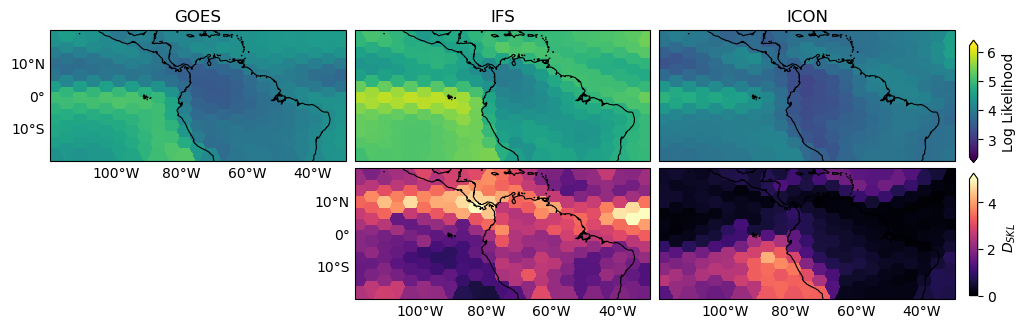

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(11.75, 3.5), subplot_kw={'projection': ccrs.PlateCarree()})

patch_likelihoods = {}

# plot likelihood maps in first row
vmin = 2.4
vmax = 6.2

# define grid boundaries and resolution
lon_min, lon_max, lat_min, lat_max = -120, -30, -20, 20
res = 0.25

grid_lon = np.arange(lon_min, lon_max + res, res)
grid_lat = np.arange(lat_min, lat_max + res, res)
lon_grid, lat_grid = np.meshgrid(grid_lon, grid_lat)

for i, dataset in enumerate(['goes', 'ifs', 'icon']):
    df = all_dataset_likelihoods[dataset]

    dataset_patch_likelihoods = get_patch_likelihood_distribution(df, column="likelihood")
    patch_likelihoods[dataset] = dataset_patch_likelihoods # store to use later for KL divergence
    points = dataset_patch_likelihoods[['lon', 'lat']].values
    mean_likelihood = dataset_patch_likelihoods['mean'].values / (64*64)

    grid_mean_likelihood = griddata(points, mean_likelihood, (lon_grid, lat_grid), method='nearest')

    ax = axs[0, i]

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    if i == 0:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

        ax.set_xticks([-100, -80, -60, -40], crs=ccrs.PlateCarree())
        ax.set_xticklabels(['100°W', '80°W', '60°W', '40°W', ])
        ax.tick_params(axis='x', length=0) 
    # Filled plot
    c = ax.pcolormesh(lon_grid, lat_grid, grid_mean_likelihood, cmap="viridis", shading='auto', vmin=vmin, vmax=vmax)

    ax.set_title(f"{dataset.upper()}")

fig.subplots_adjust(wspace=0.01, hspace=0.05)

# add a single colorbar for the second row
cbar_ax = fig.add_axes([0.91, 0.5, 0.007, 0.35])
cbar=fig.colorbar(c, cax=cbar_ax, label="Log Likelihood", extend='both')

kl_dataframes = {}

for i, dataset in enumerate(['goes', 'ifs', 'icon']):
    if dataset == 'goes':
        # remove subplot
        axs[1, i].axis('off')
        continue

    # get symmetric kl divergence between goes and ifs/icon for each patch
    kl_divs = []
    goes_patch_likelihoods = patch_likelihoods['goes']
    dataset_patch_likelihoods = patch_likelihoods[dataset]

    # build KDTree for fast nearest-neighbor search
    other_points = dataset_patch_likelihoods[['lon', 'lat']].values
    tree = cKDTree(other_points)

    for _, row in goes_patch_likelihoods.iterrows():
        lon, lat = row['lon'], row['lat']
        goes_values = row['values']

        # query nearest patch
        dist, idx = tree.query([lon, lat], k=1)
        if np.isfinite(dist):
            other_values = dataset_patch_likelihoods.iloc[idx]['values']
            kl_div = symmetric_kl(goes_values, other_values)
            kl_divs.append((lon, lat, kl_div))
        else:
            kl_divs.append((lon, lat, np.nan)) # no match found

    kl_df = pd.DataFrame(kl_divs, columns=['lon', 'lat', 'kl_divergence'])
    kl_dataframes[dataset] = kl_df

    # interpolate to grid
    points = kl_df[['lon', 'lat']].values
    kl_values = kl_df['kl_divergence'].values
    grid_kl_divergence = griddata(points, kl_values, (lon_grid, lat_grid), method='nearest')

    ax = axs[1, i]
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    

    if i == 1:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

    ax.set_xticks([-100, -80, -60, -40], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['100°W', '80°W', '60°W', '40°W', ])
    ax.tick_params(axis='x', length=0) 

    c = ax.pcolormesh(lon_grid, lat_grid, grid_kl_divergence, cmap="magma", shading='auto', vmin=0, vmax=5)

# adjust spacing between subplots
fig.subplots_adjust(wspace=0.01, hspace=0.05)

# colorbar for the second row
cbar_ax = fig.add_axes([0.91, 0.12, 0.007, 0.35])  # tweak as needed
fig.colorbar(c, cax=cbar_ax, label=r"$D_{SKL}$", extend='max')
plt.show()